<a href="https://colab.research.google.com/github/roboticengguseratvit/SAMM/blob/main/SAMM_Depth_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers accelerate
!pip install -q opencv-python pillow matplotlib

In [ ]:
import transformers

print("Transformers version:", transformers.__version__)

Transformers version: 5.15.0


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from transformers import pipeline

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
device = 0 if torch.cuda.is_available() else -1

if device == 0:
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

Using GPU: Tesla T4


In [ ]:
depth_pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=device
)

print("Depth Anything V2 loaded successfully!")

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 99.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Depth Anything V2 loaded successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving chair.jfif to chair.jfif


In [ ]:
filename = next(iter(uploaded))

image = Image.open(filename).convert("RGB")

print("Image:", filename)
print("Image size:", image.size)

Image: chair.jfif
Image size: (447, 447)


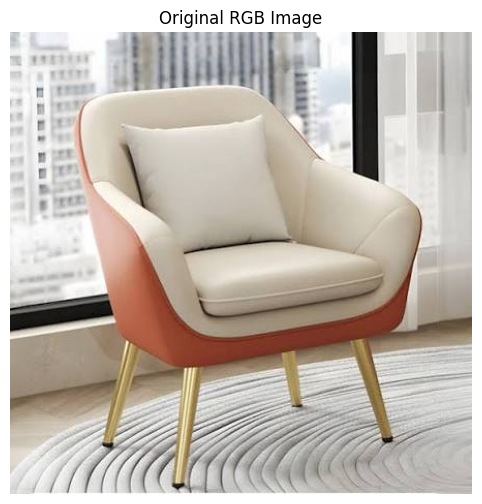

In [ ]:
plt.figure(figsize=(10, 6))

plt.imshow(image)
plt.axis("off")
plt.title("Original RGB Image")

plt.show()

In [ ]:
result = depth_pipe(image)

print("Depth estimation completed!")
print("Available outputs:", result.keys())

Depth estimation completed!
Available outputs: dict_keys(['predicted_depth', 'depth'])


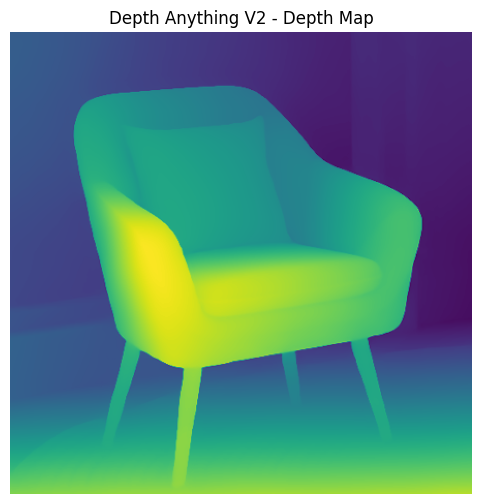

In [ ]:
depth_image = result["depth"]

plt.figure(figsize=(10, 6))

plt.imshow(depth_image)
plt.axis("off")
plt.title("Depth Anything V2 - Depth Map")

plt.show()

In [ ]:
predicted_depth = result["predicted_depth"]

print("Type:", type(predicted_depth))
print("Shape:", predicted_depth.shape)

Type: <class 'torch.Tensor'>
Shape: torch.Size([447, 447])


In [ ]:
depth_array = predicted_depth.detach().cpu().numpy()

print("Depth array shape:", depth_array.shape)
print("Minimum value:", depth_array.min())
print("Maximum value:", depth_array.max())

Depth array shape: (447, 447)
Minimum value: 0.6822621
Maximum value: 5.4687214


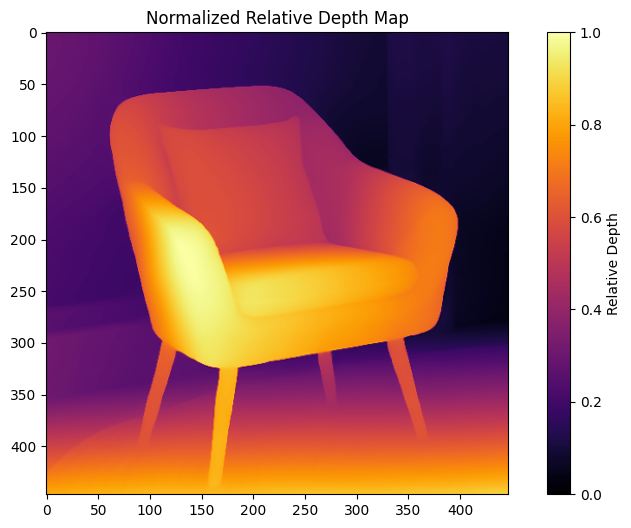

In [ ]:
depth_normalized = (
    (depth_array - depth_array.min())
    /
    (depth_array.max() - depth_array.min() + 1e-8)
)

plt.figure(figsize=(10, 6))

plt.imshow(depth_normalized, cmap="inferno")
plt.colorbar(label="Relative Depth")
plt.title("Normalized Relative Depth Map")

plt.show()

In [ ]:
#install YOLO
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 7.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

print("YOLO imported successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
YOLO imported successfully!


In [ ]:
yolo_model = YOLO("yolov8n.pt")

print("YOLOv8 loaded successfully!")

YOLOv8 loaded successfully!


In [ ]:
yolo_results = yolo_model(
    image,
    verbose=False
)

print("YOLO detection completed!")

YOLO detection completed!


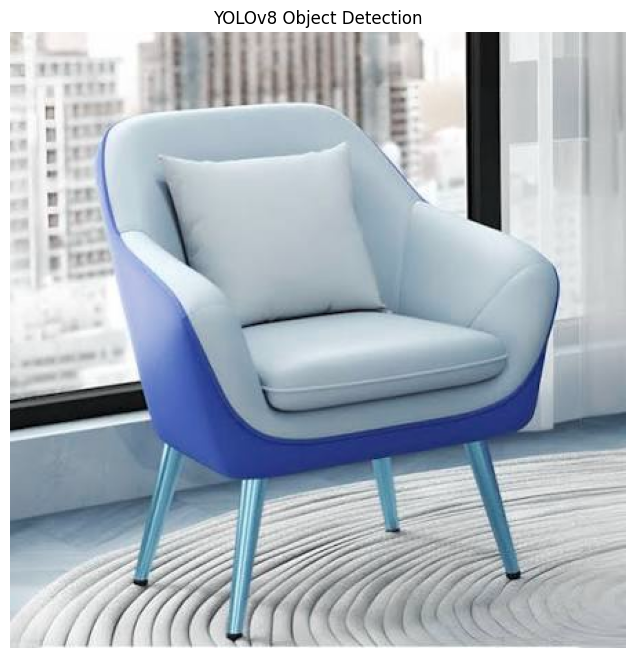

In [ ]:
annotated_image = yolo_results[0].plot()

plt.figure(figsize=(12, 8))

plt.imshow(annotated_image)
plt.axis("off")
plt.title("YOLOv8 Object Detection")

plt.show()

In [ ]:
for result in yolo_results:
    if result.boxes is None or len(result.boxes) == 0:
        print("No objects detected.")
    else:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = yolo_model.names[class_id]
            confidence = float(box.conf[0])

            print(f"{class_name}: {confidence:.3f}")

No objects detected.


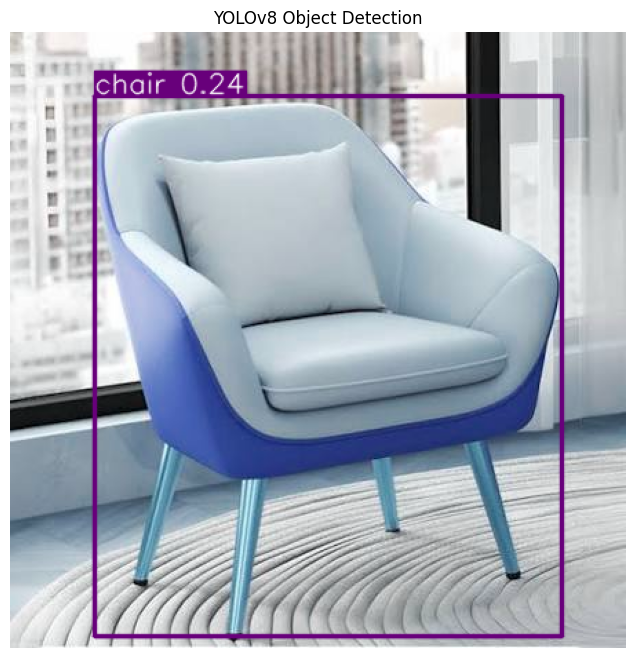

In [ ]:
yolo_results = yolo_model(
    image,
    conf=0.20,
    verbose=False
)

annotated_image = yolo_results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("YOLOv8 Object Detection")
plt.show()

In [ ]:
for result in yolo_results:
    for box in result.boxes:

        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]
        confidence = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        print(
            f"Object: {class_name} | "
            f"Confidence: {confidence:.3f} | "
            f"Box: ({int(x1)}, {int(y1)}, {int(x2)}, {int(y2)})"
        )

Object: chair | Confidence: 0.243 | Box: (61, 46, 400, 438)


In [ ]:
#connect to depth anything v2
depth_result = depth_pipe(image)

predicted_depth = depth_result["predicted_depth"]

depth_array = predicted_depth.detach().cpu().numpy()

print("Depth estimation completed!")
print("Depth shape:", depth_array.shape)

Depth estimation completed!
Depth shape: (447, 447)


In [ ]:
import cv2

original_width, original_height = image.size

depth_resized = cv2.resize(
    depth_array,
    (original_width, original_height),
    interpolation=cv2.INTER_LINEAR
)

print("Image size:", image.size)
print("Depth map size:", depth_resized.shape)

Image size: (447, 447)
Depth map size: (447, 447)


In [ ]:
target_detection = None

for result in yolo_results:
    for box in result.boxes:

        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]
        confidence = float(box.conf[0])

        if class_name == "chair":

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

            target_detection = {
                "class": class_name,
                "confidence": confidence,
                "bbox": (
                    int(x1),
                    int(y1),
                    int(x2),
                    int(y2)
                )
            }

            break

if target_detection:
    print(target_detection)
else:
    print("Chair not found.")

{'class': 'chair', 'confidence': 0.24272334575653076, 'bbox': (61, 46, 400, 438)}


In [ ]:
x1, y1, x2, y2 = target_detection["bbox"]

chair_depth = depth_resized[y1:y2, x1:x2]

print("Chair depth region:", chair_depth.shape)

Chair depth region: (392, 339)


In [ ]:
valid_depth = chair_depth[np.isfinite(chair_depth)]

median_chair_depth = np.median(valid_depth)

print("Median relative depth:", median_chair_depth)

Median relative depth: 3.39386


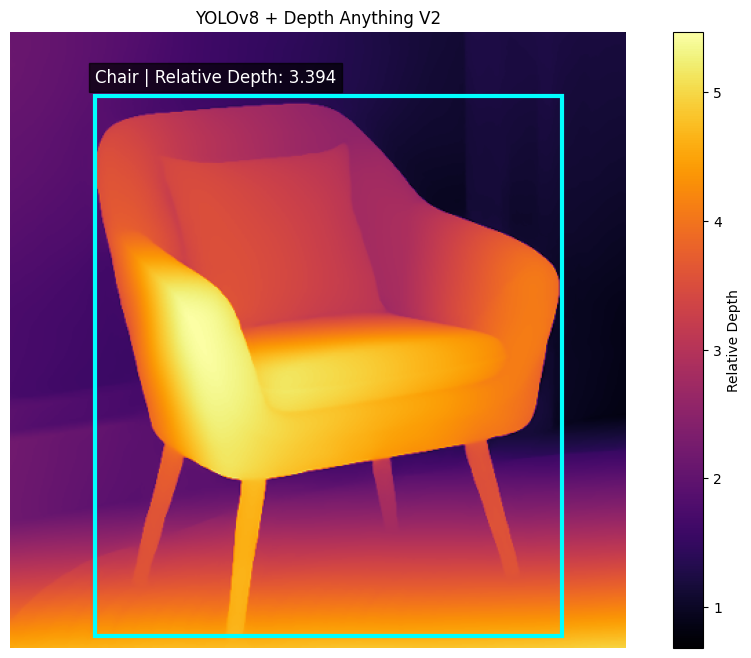

In [ ]:
plt.figure(figsize=(12, 8))

plt.imshow(depth_resized, cmap="inferno")

rectangle = plt.Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    fill=False,
    edgecolor="cyan",
    linewidth=3
)

plt.gca().add_patch(rectangle)

plt.text(
    x1,
    max(y1 - 10, 10),
    f"Chair | Relative Depth: {median_chair_depth:.3f}",
    color="white",
    fontsize=12,
    bbox=dict(facecolor="black", alpha=0.7)
)

plt.colorbar(label="Relative Depth")

plt.title("YOLOv8 + Depth Anything V2")
plt.axis("off")

plt.show()

In [ ]:
from google.colab import files

uploaded_calibration = files.upload()

Saving bottle_50cm.jpeg to bottle_50cm.jpeg
Saving bottle_75cm.jpeg to bottle_75cm.jpeg
Saving bottle_100cm.jpeg to bottle_100cm.jpeg
Saving bottle_125cm.jpeg to bottle_125cm.jpeg
Saving bottle_150cm.jpeg to bottle_150cm.jpeg


In [ ]:
actual_distances = {
    "chair_50cm.jpg": 0.50,
    "chair_75cm.jpg": 0.75,
    "chair_100cm.jpg": 1.00,
    "chair_125cm.jpg": 1.25,
    "chair_150cm.jpg": 1.50
}

print(actual_distances)

{'chair_50cm.jpg': 0.5, 'chair_75cm.jpg': 0.75, 'chair_100cm.jpg': 1.0, 'chair_125cm.jpg': 1.25, 'chair_150cm.jpg': 1.5}


In [ ]:
def get_object_depth(image, target_object="chair", confidence=0.20):

    # YOLO detection
    results = yolo_model(
        image,
        conf=confidence,
        verbose=False
    )

    target = None

    for result in results:

        for box in result.boxes:

            class_id = int(box.cls[0])
            class_name = yolo_model.names[class_id]

            if class_name == target_object:

                conf = float(box.conf[0])

                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

                target = {
                    "class": class_name,
                    "confidence": conf,
                    "bbox": (
                        int(x1),
                        int(y1),
                        int(x2),
                        int(y2)
                    )
                }

                break

        if target is not None:
            break

    if target is None:
        return None

    # Depth estimation
    depth_result = depth_pipe(image)

    predicted_depth = depth_result["predicted_depth"]

    depth_array = predicted_depth.detach().cpu().numpy()

    # Resize depth map to original image size
    width, height = image.size

    depth_resized = cv2.resize(
        depth_array,
        (width, height),
        interpolation=cv2.INTER_LINEAR
    )

    # Extract object region
    x1, y1, x2, y2 = target["bbox"]

    object_depth = depth_resized[y1:y2, x1:x2]

    # Remove invalid values
    valid_depth = object_depth[
        np.isfinite(object_depth)
    ]

    if len(valid_depth) == 0:
        return None

    # Median relative depth
    median_depth = float(
        np.median(valid_depth)
    )

    target["relative_depth"] = median_depth

    return target

In [ ]:
calibration_results = []

for filename, actual_distance in actual_distances.items():

    if filename not in uploaded_calibration:
        print(f"{filename} was not uploaded.")
        continue

    image = Image.open(filename).convert("RGB")

    result = get_object_depth(
        image,
        target_object="chair",
        confidence=0.20
    )

    if result is None:

        print(f"{filename}: Chair not detected.")

    else:

        relative_depth = result["relative_depth"]
        confidence = result["confidence"]

        calibration_results.append({
            "image": filename,
            "actual_distance": actual_distance,
            "relative_depth": relative_depth,
            "confidence": confidence
        })

        print(
            f"{filename} | "
            f"Actual = {actual_distance:.2f} m | "
            f"Relative depth = {relative_depth:.3f} | "
            f"Confidence = {confidence:.3f}"
        )

chair_50cm.jpg was not uploaded.
chair_75cm.jpg was not uploaded.
chair_100cm.jpg was not uploaded.
chair_125cm.jpg was not uploaded.
chair_150cm.jpg was not uploaded.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bottle_50cm.jpeg to bottle_50cm.jpeg
Saving bottle_75cm.jpeg to bottle_75cm.jpeg
Saving bottle_100cm.jpeg to bottle_100cm.jpeg
Saving bottle_125cm.jpeg to bottle_125cm.jpeg
Saving bottle_150cm.jpeg to bottle_150cm.jpeg


In [ ]:
print("Uploaded files:")

for filename in uploaded.keys():
    print(filename)

Uploaded files:
bottle_50cm.jpeg
bottle_75cm.jpeg
bottle_100cm.jpeg
bottle_125cm.jpeg
bottle_150cm.jpeg


In [ ]:
import os

calibration_files = [
    "bottle_50cm.jpeg",
    "bottle_75cm.jpeg",
    "bottle_100cm.jpeg",
    "bottle_125cm.jpeg",
    "bottle_150cm.jpeg"
]

print("Checking calibration images...\n")

for filename in calibration_files:
    path = f"/content/{filename}"

    if os.path.exists(path):
        print(f"✓ {filename}")
    else:
        print(f"✗ {filename} NOT FOUND")

Checking calibration images...

✓ bottle_50cm.jpeg
✓ bottle_75cm.jpeg
✓ bottle_100cm.jpeg
✓ bottle_125cm.jpeg
✓ bottle_150cm.jpeg


In [ ]:
actual_distances = {
    "bottle_50cm.jpeg": 0.50,
    "bottle_75cm.jpeg": 0.75,
    "bottle_100cm.jpeg": 1.00,
    "bottle_125cm.jpeg": 1.25,
    "bottle_150cm.jpeg": 1.50
}

print("Calibration distances:")

for filename, distance in actual_distances.items():
    print(f"{filename} → {distance:.2f} m")

Calibration distances:
bottle_50cm.jpeg → 0.50 m
bottle_75cm.jpeg → 0.75 m
bottle_100cm.jpeg → 1.00 m
bottle_125cm.jpeg → 1.25 m
bottle_150cm.jpeg → 1.50 m


In [ ]:
import os

calibration_files = [
    "bottle_50cm.jpeg",
    "bottle_75cm.jpeg",
    "bottle_100cm.jpeg",
    "bottle_125cm.jpeg",
    "bottle_150cm.jpeg"
]

print("Checking calibration images...\n")

for filename in calibration_files:
    path = f"/content/{filename}"

    if os.path.exists(path):
        print(f"✓ {filename}")
    else:
        print(f"✗ {filename} NOT FOUND")

Checking calibration images...

✓ bottle_50cm.jpeg
✓ bottle_75cm.jpeg
✓ bottle_100cm.jpeg
✓ bottle_125cm.jpeg
✓ bottle_150cm.jpeg


In [ ]:
actual_distances = {
    "bottle_50cm.jpeg": 0.50,
    "bottle_75cm.jpeg": 0.75,
    "bottle_100cm.jpeg": 1.00,
    "bottle_125cm.jpeg": 1.25,
    "bottle_150cm.jpeg": 1.50
}

for filename, distance in actual_distances.items():
    print(f"{filename} → {distance:.2f} m")

bottle_50cm.jpeg → 0.50 m
bottle_75cm.jpeg → 0.75 m
bottle_100cm.jpeg → 1.00 m
bottle_125cm.jpeg → 1.25 m
bottle_150cm.jpeg → 1.50 m


In [ ]:
print("YOLO model:", type(yolo_model))
print("Depth model:", type(depth_pipe))

YOLO model: <class 'ultralytics.models.yolo.model.YOLO'>
Depth model: <class 'transformers.pipelines.depth_estimation.DepthEstimationPipeline'>


In [ ]:
import numpy as np
import cv2
from PIL import Image

def get_object_depth(image, target_object="bottle", confidence=0.05):

    # -----------------------------
    # 1. YOLO detection
    # -----------------------------
    results = yolo_model(
        image,
        conf=confidence,
        verbose=False
    )

    target = None

    for result in results:

        if result.boxes is None:
            continue

        for box in result.boxes:

            class_id = int(box.cls[0])
            class_name = yolo_model.names[class_id]
            conf = float(box.conf[0])

            # ONLY accept the target class
            if class_name == target_object:

                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

                target = {
                    "class": class_name,
                    "confidence": conf,
                    "bbox": (
                        int(x1),
                        int(y1),
                        int(x2),
                        int(y2)
                    )
                }

                break

        if target is not None:
            break

    if target is None:
        return None

    # -----------------------------
    # 2. Depth Anything V2
    # -----------------------------
    depth_result = depth_pipe(image)

    predicted_depth = depth_result["predicted_depth"]

    depth_array = (
        predicted_depth
        .detach()
        .cpu()
        .numpy()
    )

    # -----------------------------
    # 3. Resize depth map
    # -----------------------------
    width, height = image.size

    depth_resized = cv2.resize(
        depth_array,
        (width, height),
        interpolation=cv2.INTER_LINEAR
    )

    # -----------------------------
    # 4. Object bounding box
    # -----------------------------
    x1, y1, x2, y2 = target["bbox"]

    x1 = max(0, min(x1, width - 1))
    x2 = max(0, min(x2, width))

    y1 = max(0, min(y1, height - 1))
    y2 = max(0, min(y2, height))

    object_depth = depth_resized[y1:y2, x1:x2]

    # -----------------------------
    # 5. Valid depth values
    # -----------------------------
    valid_depth = object_depth[
        np.isfinite(object_depth)
    ]

    if len(valid_depth) == 0:
        return None

    # -----------------------------
    # 6. Median depth
    # -----------------------------
    median_depth = float(
        np.median(valid_depth)
    )

    target["relative_depth"] = median_depth

    return target

In [ ]:
calibration_results = []

for filename, actual_distance in actual_distances.items():

    image_path = f"/content/{filename}"

    image = Image.open(image_path).convert("RGB")

    result = get_object_depth(
        image,
        target_object="bottle",
        confidence=0.05
    )

    if result is None:

        print(
            f"❌ {filename}: Bottle NOT detected"
        )

    else:

        calibration_results.append({
            "image": filename,
            "actual_distance": actual_distance,
            "relative_depth": result["relative_depth"],
            "confidence": result["confidence"]
        })

        print(
            f"✓ {filename} | "
            f"Actual: {actual_distance:.2f} m | "
            f"Relative depth: "
            f"{result['relative_depth']:.3f} | "
            f"Confidence: "
            f"{result['confidence']:.3f}"
        )

✓ bottle_50cm.jpeg | Actual: 0.50 m | Relative depth: 1.911 | Confidence: 0.128
✓ bottle_75cm.jpeg | Actual: 0.75 m | Relative depth: 1.117 | Confidence: 0.187
✓ bottle_100cm.jpeg | Actual: 1.00 m | Relative depth: 0.789 | Confidence: 0.061
❌ bottle_125cm.jpeg: Bottle NOT detected
✓ bottle_150cm.jpeg | Actual: 1.50 m | Relative depth: 0.478 | Confidence: 0.059


In [ ]:
image_125 = Image.open(
    "/content/bottle_125cm.jpeg"
).convert("RGB")

results_125 = yolo_model(
    image_125,
    conf=0.01,
    verbose=False
)

print("Detections at 1.25 m:\n")

for result in results_125:

    if result.boxes is None or len(result.boxes) == 0:
        print("No detections")
        continue

    for box in result.boxes:

        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]
        confidence = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        print(
            f"{class_name}: {confidence:.3f} | "
            f"Box: ({int(x1)}, {int(y1)}, "
            f"{int(x2)}, {int(y2)})"
        )

Detections at 1.25 m:

umbrella: 0.224 | Box: (1, 1, 1166, 312)
traffic light: 0.064 | Box: (888, 0, 1057, 201)
refrigerator: 0.050 | Box: (386, 962, 1198, 1598)
traffic light: 0.024 | Box: (433, 99, 808, 304)
umbrella: 0.018 | Box: (0, 2, 1171, 545)
traffic light: 0.018 | Box: (3, 1, 1194, 301)
parking meter: 0.013 | Box: (516, 641, 592, 855)
umbrella: 0.011 | Box: (5, 0, 1131, 127)
traffic light: 0.011 | Box: (887, 0, 1198, 200)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Successful measurements only
actual_distance = np.array([
    0.50,
    0.75,
    1.00,
    1.50
])

relative_depth = np.array([
    1.911,
    1.117,
    0.789,
    0.478
])

# Fit a simple polynomial relationship:
# Distance = f(relative depth)
coefficients = np.polyfit(
    relative_depth,
    actual_distance,
    2
)

print("Calibration coefficients:")
print(coefficients)

# Predicted distances
predicted_distance = np.polyval(
    coefficients,
    relative_depth
)

# Error
error = predicted_distance - actual_distance
absolute_error = np.abs(error)

print("\nCalibration Results")
print("--------------------------------")

for i in range(len(actual_distance)):
    print(
        f"Actual: {actual_distance[i]:.2f} m | "
        f"Predicted: {predicted_distance[i]:.3f} m | "
        f"Error: {absolute_error[i]:.3f} m"
    )

print("--------------------------------")

mae = np.mean(absolute_error)

print(f"Mean Absolute Error (MAE): {mae:.3f} m")

Calibration coefficients:
[    0.64408     -2.2211      2.3965]

Calibration Results
--------------------------------
Actual: 0.50 m | Predicted: 0.504 m | Error: 0.004 m
Actual: 0.75 m | Predicted: 0.719 m | Error: 0.031 m
Actual: 1.00 m | Predicted: 1.045 m | Error: 0.045 m
Actual: 1.50 m | Predicted: 1.482 m | Error: 0.018 m
--------------------------------
Mean Absolute Error (MAE): 0.024 m


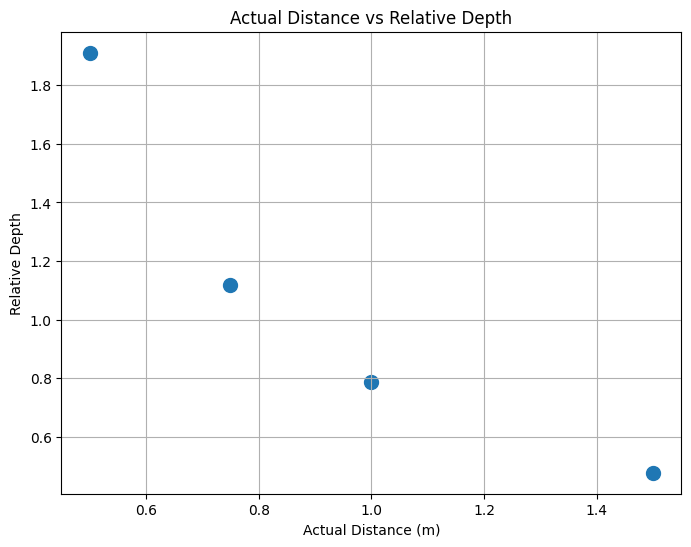

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

actual_distance = np.array([
    0.50,
    0.75,
    1.00,
    1.50
])

relative_depth = np.array([
    1.911,
    1.117,
    0.789,
    0.478
])

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_distance,
    relative_depth,
    s=100
)

plt.xlabel("Actual Distance (m)")
plt.ylabel("Relative Depth")
plt.title("Actual Distance vs Relative Depth")
plt.grid(True)

plt.show()

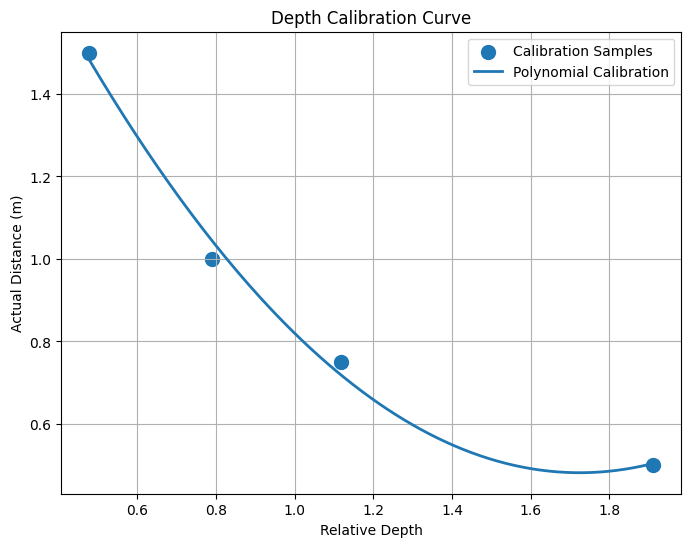

In [ ]:
# Calibration coefficients
coefficients = np.array([
    0.64408,
    -2.2211,
    2.3965
])

# Generate depth values for smooth curve
depth_range = np.linspace(
    relative_depth.min(),
    relative_depth.max(),
    200
)

predicted_distance_curve = np.polyval(
    coefficients,
    depth_range
)

plt.figure(figsize=(8, 6))

plt.scatter(
    relative_depth,
    actual_distance,
    s=100,
    label="Calibration Samples"
)

plt.plot(
    depth_range,
    predicted_distance_curve,
    linewidth=2,
    label="Polynomial Calibration"
)

plt.xlabel("Relative Depth")
plt.ylabel("Actual Distance (m)")
plt.title("Depth Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()

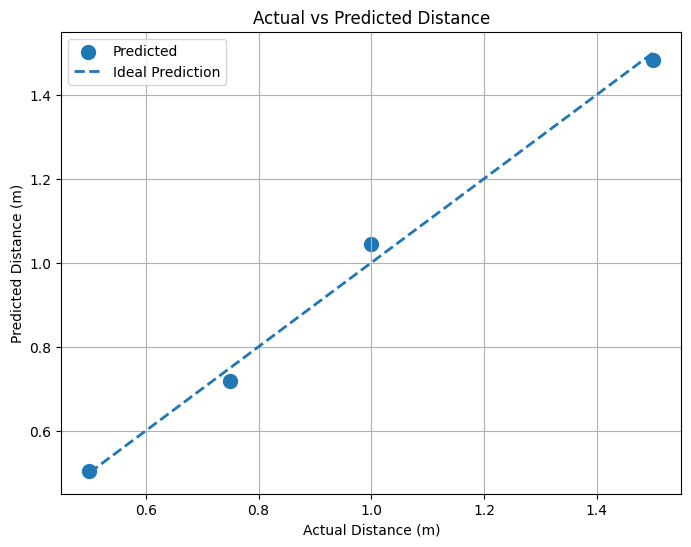

In [ ]:
predicted_distance = np.polyval(
    coefficients,
    relative_depth
)

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_distance,
    predicted_distance,
    s=100,
    label="Predicted"
)

# Perfect prediction line
min_distance = min(actual_distance)
max_distance = max(actual_distance)

plt.plot(
    [min_distance, max_distance],
    [min_distance, max_distance],
    linestyle="--",
    linewidth=2,
    label="Ideal Prediction"
)

plt.xlabel("Actual Distance (m)")
plt.ylabel("Predicted Distance (m)")
plt.title("Actual vs Predicted Distance")
plt.legend()
plt.grid(True)

plt.show()

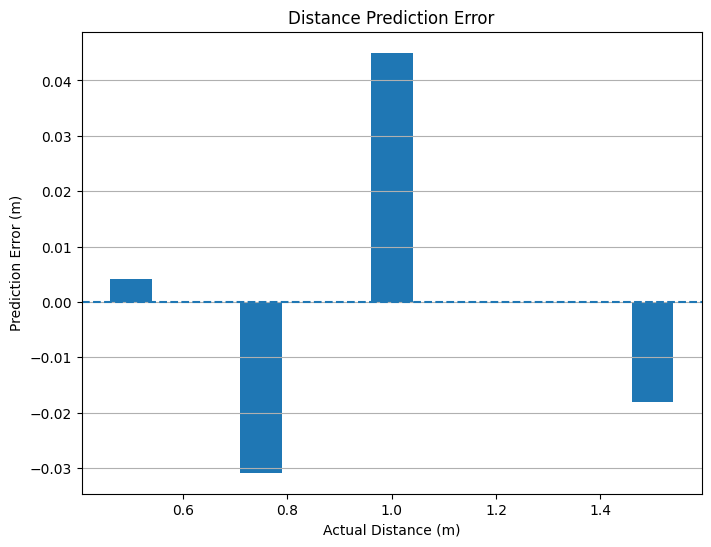

In [ ]:
errors = predicted_distance - actual_distance

plt.figure(figsize=(8, 6))

plt.bar(
    actual_distance,
    errors,
    width=0.08
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Actual Distance (m)")
plt.ylabel("Prediction Error (m)")
plt.title("Distance Prediction Error")
plt.grid(True, axis="y")

plt.show()

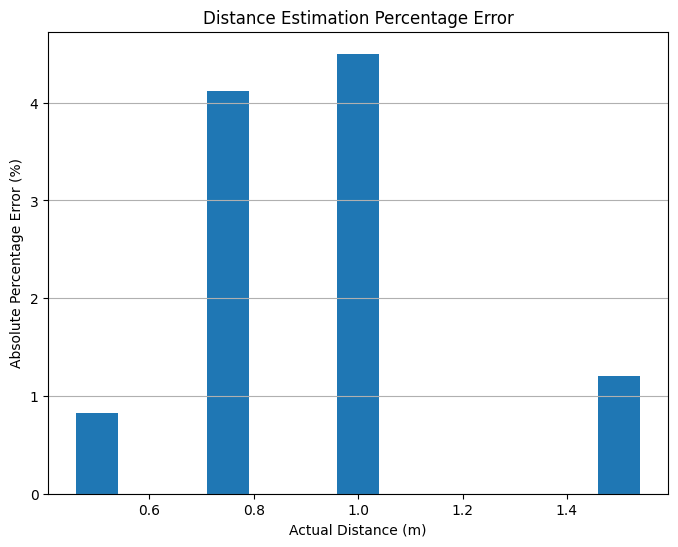

In [ ]:
percentage_error = (
    np.abs(predicted_distance - actual_distance)
    / actual_distance
) * 100

plt.figure(figsize=(8, 6))

plt.bar(
    actual_distance,
    percentage_error,
    width=0.08
)

plt.xlabel("Actual Distance (m)")
plt.ylabel("Absolute Percentage Error (%)")
plt.title("Distance Estimation Percentage Error")
plt.grid(True, axis="y")

plt.show()

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual Distance (m)": actual_distance,
    "Relative Depth": relative_depth,
    "Predicted Distance (m)": predicted_distance,
    "Absolute Error (m)": np.abs(predicted_distance - actual_distance),
    "Percentage Error (%)": percentage_error
})

results_df

,Actual Distance (m),Relative Depth,Predicted Distance (m),Absolute Error (m),Percentage Error (%)
0,0.50,1.911,0.504107,0.004107,0.821436
1,0.75,1.117,0.719143,0.030857,4.114289
2,1.00,0.789,1.045005,0.045005,4.500543
3,1.50,0.478,1.481976,0.018024,1.201588


In [ ]:
mae = np.mean(
    np.abs(predicted_distance - actual_distance)
)

rmse = np.sqrt(
    np.mean(
        (predicted_distance - actual_distance) ** 2
    )
)

mean_percentage_error = np.mean(
    percentage_error
)

print("========== CALIBRATION PERFORMANCE ==========")
print(f"MAE  : {mae:.4f} m")
print(f"RMSE : {rmse:.4f} m")
print(f"MAPE : {mean_percentage_error:.2f}%")

========== CALIBRATION PERFORMANCE ==========
MAE  : 0.0245 m
RMSE : 0.0288 m
MAPE : 2.66%


In [ ]:
#testing
from google.colab import files

test_upload = files.upload()

Saving bottle_test_150cm.jpeg to bottle_test_150cm.jpeg
Saving bottle_test_130cm.jpeg to bottle_test_130cm.jpeg
Saving bottle_test_110cm.jpeg to bottle_test_110cm.jpeg
Saving bottle_test_90cm.jpeg to bottle_test_90cm.jpeg
Saving bottle_test_60cm.jpeg to bottle_test_60cm.jpeg


In [ ]:
print("Validation files:")

for filename in test_upload.keys():
    print(filename)

Validation files:
bottle_test_150cm.jpeg
bottle_test_130cm.jpeg
bottle_test_110cm.jpeg
bottle_test_90cm.jpeg
bottle_test_60cm.jpeg


In [ ]:
test_distances = {
    "bottle_test_60cm.jpeg": 0.60,
    "bottle_test_90cm.jpeg": 0.90,
    "bottle_test_110cm.jpeg": 1.10,
    "bottle_test_130cm.jpeg": 1.30,
    "bottle_test_140cm.jpeg": 1.40
}

for filename, distance in test_distances.items():
    print(f"{filename} → {distance:.2f} m")

bottle_test_60cm.jpeg → 0.60 m
bottle_test_90cm.jpeg → 0.90 m
bottle_test_110cm.jpeg → 1.10 m
bottle_test_130cm.jpeg → 1.30 m
bottle_test_140cm.jpeg → 1.40 m


In [ ]:
validation_results = []

for filename, actual_distance in test_distances.items():

    image_path = f"/content/{filename}"

    image = Image.open(image_path).convert("RGB")

    result = get_object_depth(
        image,
        target_object="bottle",
        confidence=0.05
    )

    if result is None:

        print(f"❌ {filename}: Bottle NOT detected")

    else:

        validation_results.append({
            "image": filename,
            "actual_distance": actual_distance,
            "relative_depth": result["relative_depth"],
            "confidence": result["confidence"]
        })

        print(
            f"✓ {filename} | "
            f"Actual: {actual_distance:.2f} m | "
            f"Relative depth: {result['relative_depth']:.3f} | "
            f"Confidence: {result['confidence']:.3f}"
        )

✓ bottle_test_60cm.jpeg | Actual: 0.60 m | Relative depth: 1.471 | Confidence: 0.122
✓ bottle_test_90cm.jpeg | Actual: 0.90 m | Relative depth: 0.947 | Confidence: 0.066
❌ bottle_test_110cm.jpeg: Bottle NOT detected
✓ bottle_test_130cm.jpeg | Actual: 1.30 m | Relative depth: 0.472 | Confidence: 0.119
❌ bottle_test_140cm.jpeg: Bottle NOT detected


In [ ]:
coefficients

array([    0.64408,     -2.2211,      2.3965])

In [ ]:
validation_df = pd.DataFrame(
    validation_results
)

validation_df["predicted_distance"] = np.polyval(
    coefficients,
    validation_df["relative_depth"]
)

validation_df

,image,actual_distance,relative_depth,confidence,predicted_distance
0,bottle_test_60cm.jpeg,0.6,1.471301,0.122148,0.522850
1,bottle_test_90cm.jpeg,0.9,0.946981,0.066044,0.870754
2,bottle_test_130cm.jpeg,1.3,0.471805,0.118612,1.491946


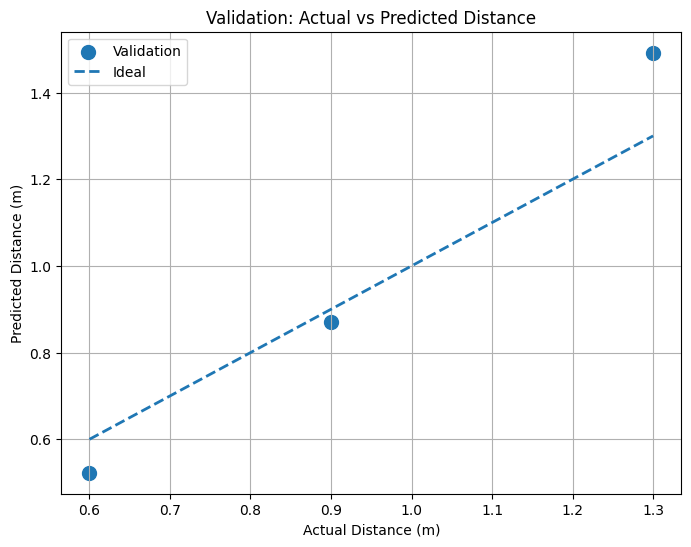

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    validation_df["actual_distance"],
    validation_df["predicted_distance"],
    s=100,
    label="Validation"
)

min_d = validation_df["actual_distance"].min()
max_d = validation_df["actual_distance"].max()

plt.plot(
    [min_d, max_d],
    [min_d, max_d],
    linestyle="--",
    linewidth=2,
    label="Ideal"
)

plt.xlabel("Actual Distance (m)")
plt.ylabel("Predicted Distance (m)")
plt.title("Validation: Actual vs Predicted Distance")

plt.legend()
plt.grid(True)

plt.show()

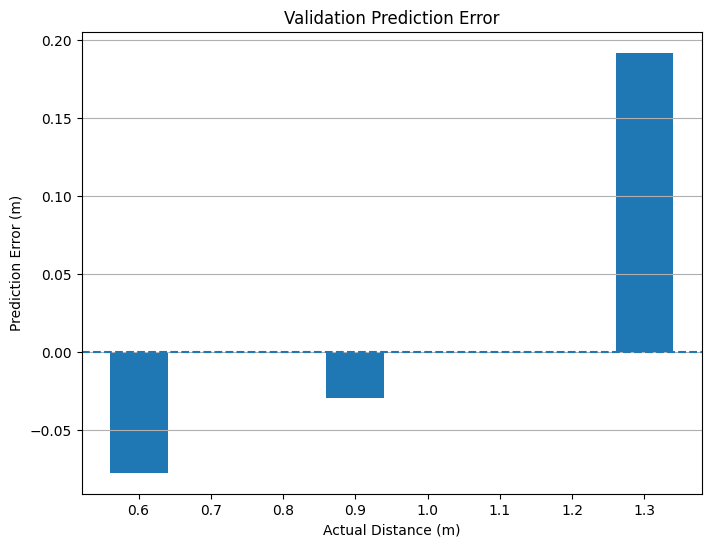

In [ ]:
validation_df["error"] = (
    validation_df["predicted_distance"]
    - validation_df["actual_distance"]
)

plt.figure(figsize=(8, 6))

plt.bar(
    validation_df["actual_distance"],
    validation_df["error"],
    width=0.08
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Actual Distance (m)")
plt.ylabel("Prediction Error (m)")
plt.title("Validation Prediction Error")

plt.grid(True, axis="y")

plt.show()

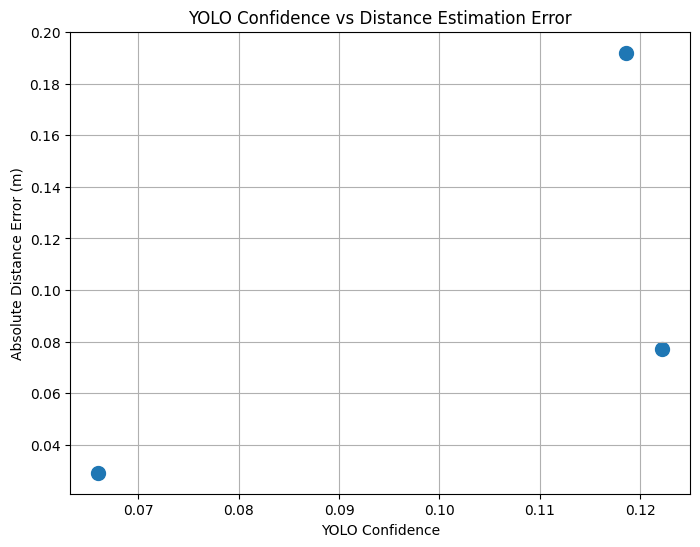

In [ ]:
validation_df["absolute_error"] = abs(
    validation_df["predicted_distance"]
    -
    validation_df["actual_distance"]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    validation_df["confidence"],
    validation_df["absolute_error"],
    s=100
)

plt.xlabel("YOLO Confidence")
plt.ylabel("Absolute Distance Error (m)")
plt.title("YOLO Confidence vs Distance Estimation Error")

plt.grid(True)

plt.show()